# EDA : Publications PubMed du CHU de Rennes

Exploration rapide du corpus : qualité des données, couverture temporelle, vocabulaire, profil des auteurs.
Point de départ avant de lancer les modèles NLP.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# Config matplotlib
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Chemin vers les donnees
DATA_PATH = Path("../data/pubmed_chu_rennes.jsonl")

print(f"Chemin : {DATA_PATH}")
print(f"Existe ? {DATA_PATH.exists()}")

Chemin : ../data/pubmed_chu_rennes.jsonl
Existe ? True


## 1. Chargement des données

In [3]:
# Chargement
df = pd.read_json(DATA_PATH, lines=True)

print(f"Nombre de notices : {len(df)}")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nTypes :")
print(df.dtypes)
print(f"Objet authors : {(df['authors'][0])}")
print(f"\nPremière ligne :")
df.iloc[0]

Nombre de notices : 9432

Colonnes : ['pmid', 'title', 'abstract', 'journal', 'year', 'mesh_terms', 'authors', 'n_authors']

Types :
pmid           int64
title            str
abstract         str
journal          str
year             str
mesh_terms    object
authors       object
n_authors      int64
dtype: object
Objet authors : [{'last_name': 'Joubert', 'fore_name': 'Michael', 'collective_name': '', 'affiliations': ['Diabetes Care Unit, CHU Caen, UNICAEN, Caen, France.']}, {'last_name': 'Amouyal', 'fore_name': 'Chloé', 'collective_name': '', 'affiliations': ['Diabetology Department, Pitié-Salpêtrière Hospital, INSERM Nutriomic Team, Sorbonne Université, AP-HP, Paris, France.']}, {'last_name': 'Bismuth', 'fore_name': 'Elise', 'collective_name': '', 'affiliations': ['Department of Pediatric Endocrinology and Diabetology, Robert-Debré Hospital, Assistance Publique Hôpitaux de Paris, University of Paris, Paris, France.']}, {'last_name': 'Borot', 'fore_name': 'Sophie', 'collective_name': '

pmid                                                   42750105
title         Rethinking Meal Management in Automated Insuli...
abstract      To review the spectrum of meal-management stra...
journal                          Diabetes, obesity & metabolism
year                                                       2026
mesh_terms                                                   []
authors       [{'last_name': 'Joubert', 'fore_name': 'Michae...
n_authors                                                    10
Name: 0, dtype: object

In [4]:
# Aperçu general
df.head(3)

,pmid,title,abstract,journal,year,mesh_terms,authors,n_authors
0,42750105,Rethinking Meal Management in Automated Insuli...,To review the spectrum of meal-management stra...,"Diabetes, obesity & metabolism",2026,[],"[{'last_name': 'Joubert', 'fore_name': 'Michae...",10
1,42750097,Reply to Duchemin et al. identification of maj...,,British journal of clinical pharmacology,2026,[],"[{'last_name': 'Broekstra', 'fore_name': 'Dieu...",9
2,42749085,AI-assisted handheld echocardiography for hosp...,Timely echocardiography remains difficult beca...,International journal of cardiology,2026,[],"[{'last_name': 'Paineau', 'fore_name': 'Mathie...",14


## 2. Nettoyage et validation

In [8]:
# Conversion de year en numeric (il y a peut-etre des annees manquantes ou mal formees)
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Longueurs
df['title_len'] = df['title'].fillna('').str.len()
df['abstract_len'] = df['abstract'].fillna('').str.len()
df['n_mesh'] = df['mesh_terms'].apply(lambda x: len(x) if isinstance(x, list) else 0)

print("=== QUALITE DES DONNEES ===")
print(f"\nValeurs manquantes :")
print(df.isnull().sum())

print(f"\nTitre vide : {(df['title_len'] == 0).sum()}")
print(f"Abstract vide : {(df['abstract_len'] == 0).sum()}")
print(f"Pas de mots-cles MeSH : {(df['n_mesh'] == 0).sum()}")
print(f"Annee manquante ou invalide : {df['year'].isnull().sum()}")
print(df[df['year'].isnull()][['year', 'title', 'abstract']])

=== QUALITE DES DONNEES ===

Valeurs manquantes :
pmid            0
title           0
abstract        0
journal         0
year            3
mesh_terms      0
authors         0
n_authors       0
title_len       0
abstract_len    0
n_mesh          0
dtype: int64

Titre vide : 0
Abstract vide : 1456
Pas de mots-cles MeSH : 1453
Annee manquante ou invalide : 3
      year                                              title  \
9398   NaN  [Esophagectomy without thoracotomy. Comparison...   
9399   NaN  [Parietal metastases and early local recurrenc...   
9408   NaN   ["Piggyback" method in hepatic transplantation].   

                                               abstract  
9398  From 1983 to 1989, 96 oesophagectomies (30% of...  
9399                                                     
9408  Using the traditional technique for liver tran...  


In [9]:
# Statistiques de longueur
print("\n=== LONGUEURS DE TEXTE ===")
print(f"\nTitre :")
print(df['title_len'].describe())

print(f"\nAbstract :")
print(df['abstract_len'].describe())

print(f"\nMots-cles MeSH par notice :")
print(df['n_mesh'].describe())


=== LONGUEURS DE TEXTE ===

Titre :
count    9432.000000
mean      114.365882
std        45.400157
min         6.000000
25%        85.000000
50%       111.000000
75%       138.000000
max       536.000000
Name: title_len, dtype: float64

Abstract :
count    9432.000000
mean     1349.441052
std       757.432735
min         0.000000
25%       973.750000
50%      1544.000000
75%      1808.000000
max      8064.000000
Name: abstract_len, dtype: float64

Mots-cles MeSH par notice :
count    9432.000000
mean        9.731870
std         6.256668
min         0.000000
25%         6.000000
50%        10.000000
75%        14.000000
max        36.000000
Name: n_mesh, dtype: float64


In [14]:
# Exemple d'une notice complete
print("=== EXEMPLE DE NOTICE COMPLETE ===")
idx = df[df['abstract_len'] > 500].index[3000]  # prendre une avec un bon abstract
print(f"PMID : {df.loc[idx, 'pmid']}")
print(f"\nTitre : {df.loc[idx, 'title']}")
print(f"\nJournal : {df.loc[idx, 'journal']}")
print(f"Annee : {df.loc[idx, 'year']}")
print(f"\nAbstract ({df.loc[idx, 'abstract_len']} caracteres) :\n{df.loc[idx, 'abstract'][:500]}...")
print(f"\nMeSH terms ({df.loc[idx, 'n_mesh']}) :")
for term in df.loc[idx, 'mesh_terms'][:5]:
    print(f"  - {term}")

=== EXEMPLE DE NOTICE COMPLETE ===
PMID : 35579092

Titre : Venous thromboembolism during systemic inflammatory and autoimmune diseases associated with myelodysplastic syndromes, chronic myelomonocytic leukaemia and myelodysplastic/myeloproliferative neoplasms: a French multicentre retrospective case-control study.

Journal : Clinical and experimental rheumatology
Annee : 2022.0

Abstract (1965 caracteres) :
Myelodysplastic syndromes (MDS) and chronic myelomonocytic leukaemia (CMML) are associated with systemic inflammatory and autoimmune diseases (SIADs) in 10-30% of cases. The aims of this study were (i) to evaluate the prevalence of venous thromboembolism VTE in patients presenting with both MDS/CMML and SIADs, (ii) to describe risk factors associated with thrombosis, and (iii) to analyse the impact of VTE on overall survival and transformation to acute myeloid leukaemia in comparison to patients...

MeSH terms (7) :
  - Autoimmune Diseases
  - Case-Control Studies
  - Humans
  - Le

## 3. Couverture temporelle

In [16]:
# Filtrer les annees valides
df_valid_year = df[df['year'].notna()].copy()
df_valid_year['decade'] = (df_valid_year['year'] // 10 * 10).astype(int)

print(f"\n=== COUVERTURE TEMPORELLE ===")
print(f"Notices avec annee valide : {len(df_valid_year)} / {len(df)}")
print(f"\nPeriode : {df_valid_year['year'].min():.0f} - {df_valid_year['year'].max():.0f}")

# Par annee
by_year = df_valid_year.groupby('year').size().sort_index()
print(f"\nNotices par annee (top 10) :")
print(by_year.tail(10))

# Par decennie
by_decade = df_valid_year.groupby('decade').size().sort_index()
print(f"\nNotices par decennie :")
print(by_decade)


=== COUVERTURE TEMPORELLE ===
Notices avec annee valide : 9429 / 9432

Periode : 1990 - 2026

Notices par annee (top 10) :
year
2017.0    485
2018.0    514
2019.0    636
2020.0    735
2021.0    845
2022.0    817
2023.0    735
2024.0    772
2025.0    877
2026.0    864
dtype: int64

Notices par decennie :
decade
1990      77
2000     589
2010    3118
2020    5645
dtype: int64


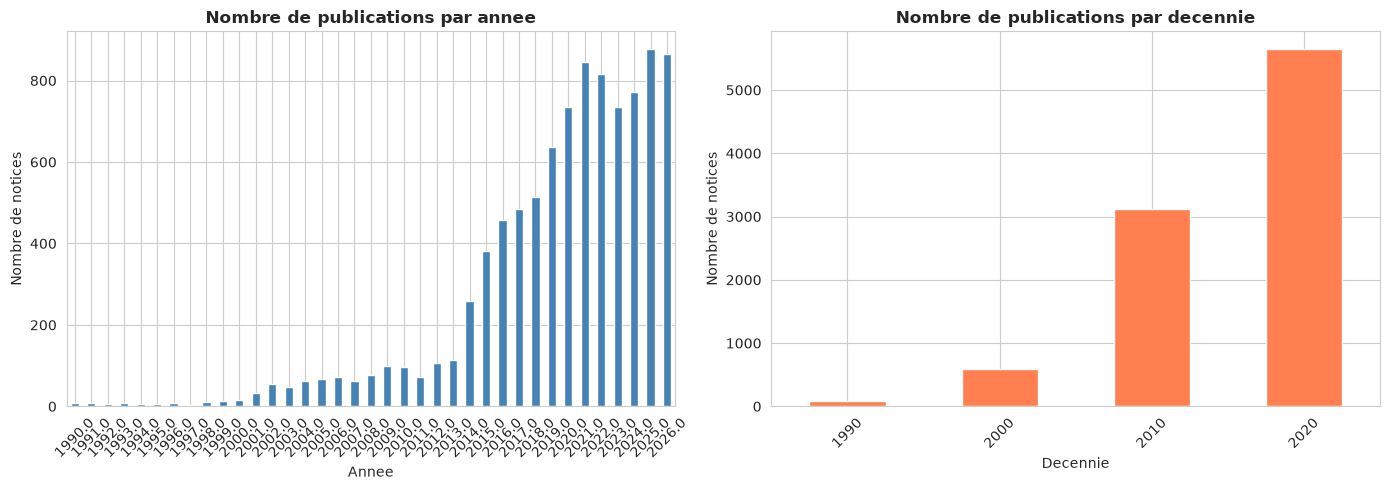

Graphiques : distribution temporelle


In [17]:
# Visualisation temporelle
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Par annee
by_year.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Nombre de publications par annee', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Annee')
axes[0].set_ylabel('Nombre de notices')
axes[0].tick_params(axis='x', rotation=45)

# Par decennie
by_decade.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Nombre de publications par decennie', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Decennie')
axes[1].set_ylabel('Nombre de notices')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Graphiques : distribution temporelle")

## 4. Journaux et publications

=== JOURNAUX ===
Nombre de journaux differents : 1696

Top 15 journaux :
journal
Progres en urologie : journal de l'Association francaise d'urologie et de la Societe francaise d'urologie    188
European heart journal. Cardiovascular Imaging                                                               116
Archives of cardiovascular diseases                                                                          103
PloS one                                                                                                      91
Bulletin du cancer                                                                                            84
La Revue du praticien                                                                                         83
Orthopaedics & traumatology, surgery & research : OTSR                                                        75
Journal of gynecology obstetrics and human reproduction                                                       75
Anaesthesia, cr

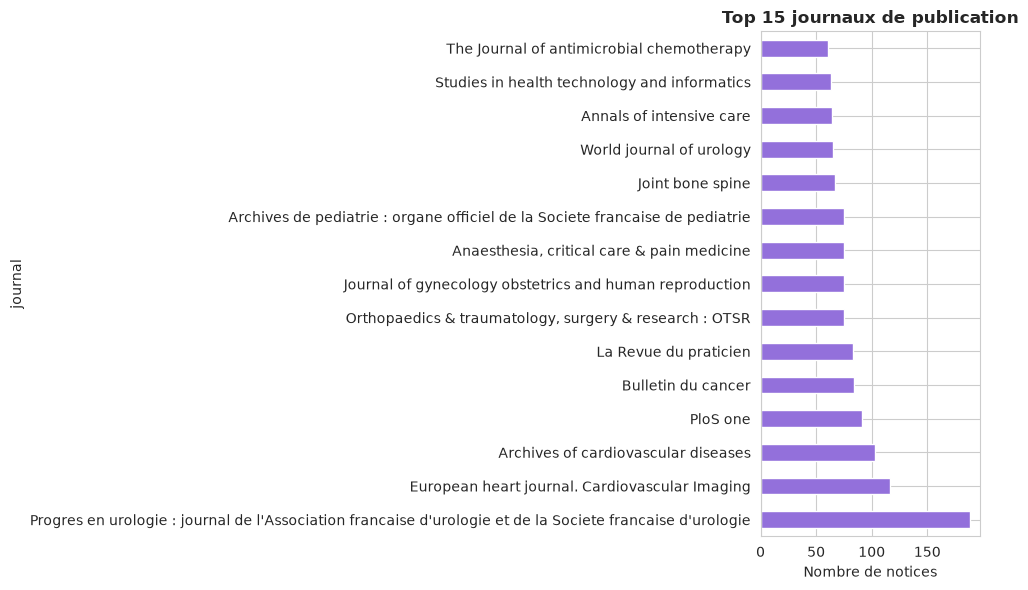

In [18]:
print("=== JOURNAUX ===")
print(f"Nombre de journaux differents : {df['journal'].nunique()}")

top_journals = df['journal'].value_counts().head(15)
print(f"\nTop 15 journaux :")
print(top_journals)

# Visualisation
top_journals.plot(kind='barh', figsize=(10, 6), color='mediumpurple')
plt.title('Top 15 journaux de publication', fontsize=12, fontweight='bold')
plt.xlabel('Nombre de notices')
plt.tight_layout()
plt.show()

## 5. Mots-cles MeSH : vocabulaire medical

In [19]:
# Extraire tous les MeSH terms
all_mesh = []
for mesh_list in df['mesh_terms']:
    if isinstance(mesh_list, list):
        all_mesh.extend(mesh_list)

mesh_counts = Counter(all_mesh)

print(f"=== VOCABULAIRE MeSH ===")
print(f"Nombre de termes MeSH distincts : {len(mesh_counts)}")
print(f"Total de tags MeSH : {len(all_mesh)}")
print(f"Moyenne par notice : {len(all_mesh) / len(df):.2f}")

print(f"\nTop 20 termes MeSH :")
for term, count in mesh_counts.most_common(20):
    pct = 100 * count / len(df)
    print(f"  {term:40s} : {count:4d} ({pct:5.1f}%)")

=== VOCABULAIRE MeSH ===
Nombre de termes MeSH distincts : 8655
Total de tags MeSH : 91791
Moyenne par notice : 9.73

Top 20 termes MeSH :
  Humans                                   : 7758 ( 82.3%)
  Female                                   : 4024 ( 42.7%)
  Male                                     : 3719 ( 39.4%)
  Middle Aged                              : 2568 ( 27.2%)
  Adult                                    : 2286 ( 24.2%)
  Aged                                     : 2125 ( 22.5%)
  Retrospective Studies                    : 1500 ( 15.9%)
  France                                   : 1372 ( 14.5%)
  Treatment Outcome                        : 1209 ( 12.8%)
  Prospective Studies                      :  877 (  9.3%)
  Aged, 80 and over                        :  767 (  8.1%)
  Adolescent                               :  743 (  7.9%)
  Child                                    :  681 (  7.2%)
  Young Adult                              :  656 (  7.0%)
  Risk Factors                     

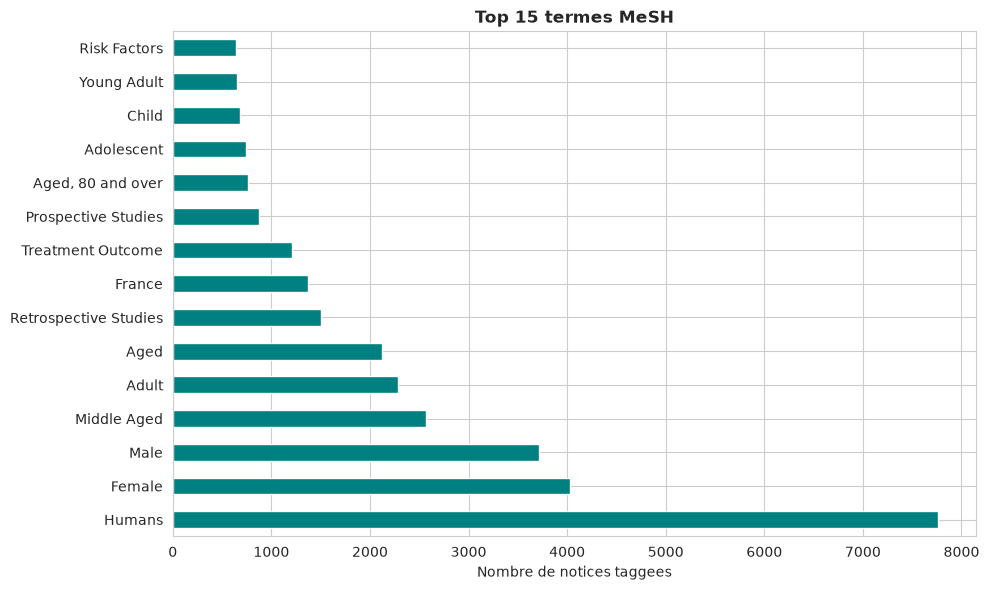

In [20]:
# Visualisation top MeSH
top_mesh = dict(mesh_counts.most_common(15))

plt.figure(figsize=(10, 6))
pd.Series(top_mesh).plot(kind='barh', color='teal')
plt.title('Top 15 termes MeSH', fontsize=12, fontweight='bold')
plt.xlabel('Nombre de notices taggees')
plt.tight_layout()
plt.show()

## 6. Auteurs et demographics

=== AUTEURS ===
Nombre total d'auteurs (comptage brut) : 132917

Auteurs par notice :
count    9432.000000
mean       14.092133
std        15.553851
min         1.000000
25%         6.000000
50%         9.000000
75%        18.000000
max       365.000000
Name: n_authors, dtype: float64


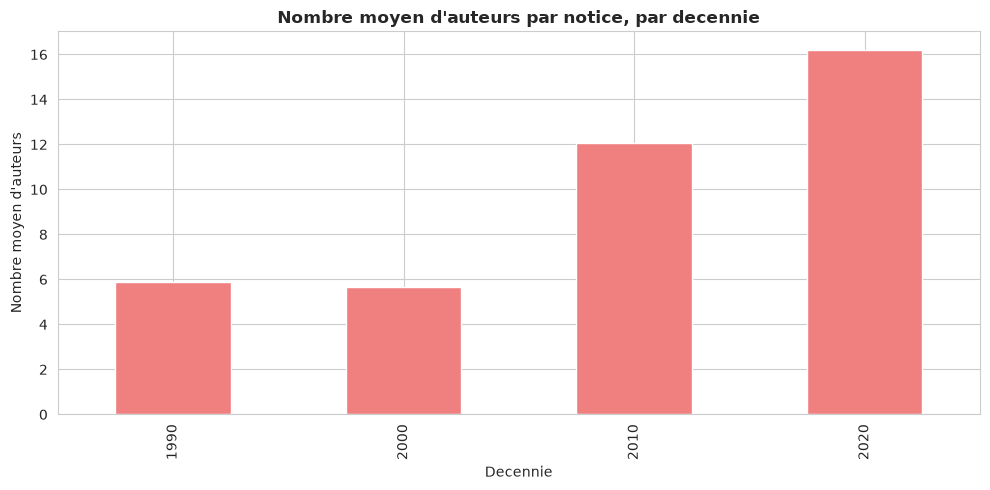

In [21]:
print("=== AUTEURS ===")
print(f"Nombre total d'auteurs (comptage brut) : {df['n_authors'].sum()}")
print(f"\nAuteurs par notice :")
print(df['n_authors'].describe())

# Evol dans le temps
df_valid_year['n_authors'].groupby(df_valid_year['decade']).mean().plot(
    kind='bar', figsize=(10, 5), color='lightcoral'
)
plt.title('Nombre moyen d\'auteurs par notice, par decennie', fontsize=12, fontweight='bold')
plt.xlabel('Decennie')
plt.ylabel('Nombre moyen d\'auteurs')
plt.tight_layout()
plt.show()

In [22]:
# Extraire les noms de famille les plus productifs
all_authors = []
for author_list in df['authors']:
    if isinstance(author_list, list):
        for author in author_list:
            if isinstance(author, dict) and author.get('last_name'):
                all_authors.append(author['last_name'])

author_counts = Counter(all_authors)

print(f"\nAuteurs distincts : {len(author_counts)}")
print(f"\nTop 15 auteurs (par nombre de publications) :")
for name, count in author_counts.most_common(15):
    print(f"  {name:20s} : {count:3d}")


Auteurs distincts : 33082

Top 15 auteurs (par nombre de publications) :
  Donal                : 472
  Bensalah             : 240
  Mathieu              : 237
  Tattevin             : 220
  Peyronnet            : 218
  Gangneux             : 212
  Leclercq             : 205
  Bonnet               : 182
  Houot                : 176
  Lavoué               : 172
  Odent                : 169
  Rioux-Leclercq       : 165
  Martins              : 159
  Michel               : 157
  Thibault             : 155


## 7. Estimation du genre des auteurs (optionnel, avec limitations)

In [23]:
# NOTE : Cette section est optionnelle et approximative.
# L'inference du genre a partir du prenom a des limites evidentes.
# A utiliser qu'a titre illustratif.

try:
    # Essayer avec gender-guesser (a installer separement)
    import gender_guesser.detector as gender
    d = gender.Detector(case_sensitive=False)
    GENDER_GUESSER_AVAILABLE = True
except ImportError:
    GENDER_GUESSER_AVAILABLE = False
    print("gender_guesser non installe. Sautage de la section ")
    print("Pour l'installer : pip install gender-guesser")

if GENDER_GUESSER_AVAILABLE:
    print("=== ESTIMATION DU GENRE (via gender-guesser) ===")
    
    # Extraire les prenoms
    first_names = []
    for author_list in df['authors']:
        if isinstance(author_list, list):
            for author in author_list:
                if isinstance(author, dict) and author.get('fore_name'):
                    # Prendre le premier mot du fore_name
                    first_word = author['fore_name'].split()[0]
                    if first_word:
                        first_names.append(first_word)
    
    # Deviner le genre (attention : approximatif et avec biais)
    genders = [d.get_gender(name) for name in first_names]
    gender_counts = Counter(genders)
    
    print(f"\nPrenoms distincts : {len(set(first_names))}")
    print(f"Distribution estimee :")
    for g, count in gender_counts.most_common():
        pct = 100 * count / len(genders)
        print(f"  {g:15s} : {count:4d} ({pct:5.1f}%)")
    
    print("\n[!] ATTENTION : Ces chiffres sont une estimation grossiere.")
    print("gender-guesser a des taux d'erreur eleves pour les prenoms internationaux/ambigus.")

gender_guesser non installe. Sautage de la section 
Pour l'installer : pip install gender-guesser


## 8. Bruit dans les affiliations (verification manuelle)

In [ ]:
# Extraire toutes les affiliations mentionnees
all_affiliations = []
for author_list in df['authors']:
    if isinstance(author_list, list):
        for author in author_list:
            if isinstance(author, dict):
                affil_list = author.get('affiliations', [])
                if isinstance(affil_list, list):
                    all_affiliations.extend(affil_list)

print(f"=== VERIFICATION DES AFFILIATIONS ===")
print(f"Total d'affiliations extraites : {len(all_affiliations)}")
print(f"Affiliations non-vides : {len([a for a in all_affiliations if a.strip()])}")

# Filtrer celles qui mentionnent Rennes
rennes_affils = [a for a in all_affiliations if 'rennes' in a.lower()]
print(f"\nAffiliations mentionnant 'Rennes' : {len(rennes_affils)}")

print(f"\nExemples d'affiliations (5 premieres) :")
for i, a in enumerate(all_affiliations[:5]):
    if a.strip():
        print(f"  {i+1}. {a[:100]}..." if len(a) > 100 else f"  {i+1}. {a}")

## 9. Resume et recommandations

In [ ]:
print("""\n╔════════════════════════════════════════════════════════════════╗
║                     RESUME DE L'EDA                                ║
╚════════════════════════════════════════════════════════════════╝

📊 CORPUS
  • Taille : {n} notices
  • Periode : {year_min:.0f} - {year_max:.0f}
  • Completude : {pct_abstract:.1f}% avec abstract

📝 TEXTES
  • Abstract moyen : {abstract_mean:.0f} caracteres
  • Titre moyen : {title_mean:.0f} caracteres

🏷️  METADATA
  • Termes MeSH distincts : {n_mesh}
  • Journaux : {n_journals}
  • Auteurs moyens/notice : {n_auth_mean:.1f}

✅ RECOMMANDATIONS POUR LE NLP

1. TACHES PRIORITAIRES :
   → Classification MeSH multi-label (TF-IDF vs Transformers)
   → Topic modeling temporel (LDA/BERTopic par decennie)

2. DONNEES A PREPARER :
   → Garder que les notices avec abstract complet
   → Normaliser les annees invalides
   → Tokenization et nettoyage texte pour TF-IDF

3. BASELINES A CONSTRUIRE :
   → TF-IDF + logistic regression pour classification MeSH
   → Sentence embeddings pré-entraînés (SentenceTransformers)

4. ANALYSE COMPLÉMENTAIRE :
   → Genre des auteurs (avec caveats methodologiques)
   → Evolution des methodologies (keywords : RCT, meta-analysis, etc.)
   → Collaborations inter-services (network analysis)

""".format(
    n=len(df),
    year_min=df_valid_year['year'].min(),
    year_max=df_valid_year['year'].max(),
    pct_abstract=100*(df['abstract_len'] > 0).sum() / len(df),
    abstract_mean=df[df['abstract_len'] > 0]['abstract_len'].mean(),
    title_mean=df['title_len'].mean(),
    n_mesh=len(mesh_counts),
    n_journals=df['journal'].nunique(),
    n_auth_mean=df['n_authors'].mean(),
))

## 10. Export pour les etapes suivantes

In [ ]:
# Sauvegarder le dataframe nettoyé avec les colonnes derivees
output_path = Path("../data/processed/pubmed_chu_rennes_processed.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

# Garder les colonnes utiles et dropper les listes (ca gere pas bien csv)
df_export = df[['pmid', 'title', 'abstract', 'journal', 'year', 'n_authors']].copy()
df_export['decade'] = (df_export['year'] // 10 * 10).astype('Int64')

df_export.to_csv(output_path, index=False)

print(f"✅ Donnees exportees vers : {output_path}")
print(f"   {len(df_export)} lignes x {len(df_export.columns)} colonnes")

# Aussi exporter les mesh_terms et authors en format traitable
mesh_export_path = Path("../data/processed/mesh_terms.json")
df[['pmid', 'mesh_terms']].to_json(mesh_export_path, orient='records', indent=2)
print(f"✅ Termes MeSH exportes vers : {mesh_export_path}")

authors_export_path = Path("../data/processed/authors.json")
df[['pmid', 'authors']].to_json(authors_export_path, orient='records', indent=2)
print(f"✅ Auteurs exportes vers : {authors_export_path}")